<a href="https://colab.research.google.com/github/shetty-23/Computer-vision---Assignment-1/blob/feature%2Ftask3-and-4-yolo/Assignment_1_Computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split


In [ ]:
# 1. Setup Paths
base_path = Path("/content/drive/MyDrive/gopro_deblur")
# Pointing to the actual subdirectories containing the .png files
blur_dir = base_path / "blur" / "images"
sharp_dir = base_path / "sharp" / "images"

In [ ]:
# Searching for .png files in the nested 'images' directory
filenames = sorted([f.name for f in blur_dir.glob("*.png")])

if len(filenames) == 0:
    print(f"No .png files found in {blur_dir}. Please check your path.")
else:
    print(f"Found {len(filenames)} files. Splitting into train, val, and test...")
    train_files, temp_files = train_test_split(filenames, test_size=0.3, random_state=42)
    val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42)
    print(f"Splits created: Train({len(train_files)}), Val({len(val_files)}), Test({len(test_files)})")

def move_to_split(file_list, split_name):
    for fname in file_list:
        for folder in ["blur", "sharp"]:
            dest = base_path / "processed" / split_name / folder
            dest.mkdir(parents=True, exist_ok=True)

            # Source files are in the 'images' subfolder
            src_file = base_path / folder / "images" / fname
            if src_file.exists():
                shutil.copy(src_file, dest / fname)
            else:
                print(f"Warning: Source file not found: {src_file}")

Found 1029 files. Splitting into train, val, and test...
Splits created: Train(720), Val(154), Test(155)


In [ ]:
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

def get_blur_score(image_path):
    image = cv2.imread(str(image_path))
    if image is None: return 0
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

print("Calculating blur scores...")
scores = []
for fname in tqdm(filenames):
    path = blur_dir / fname
    scores.append(get_blur_score(path))

# Create DataFrame for analysis
df_blur = pd.DataFrame({'filename': filenames, 'score': scores})

# Define thresholds for categories (Quantile-based for even distribution)
# You can adjust these fixed values if you prefer specific variance ranges
low, high = df_blur['score'].quantile([0.33, 0.66])

def categorize(s):
    if s <= low: return 'Severe'
    if s <= high: return 'Medium'
    return 'Mild'

df_blur['category'] = df_blur['score'].apply(categorize)
print("\nBlur Category Distribution:")
print(df_blur['category'].value_counts())

# Perform Stratified Split (70/15/15)
train_list, val_list, test_list = [], [], []

for cat in ['Mild', 'Medium', 'Severe']:
    cat_files = df_blur[df_blur['category'] == cat]['filename'].tolist()
    tr, temp = train_test_split(cat_files, test_size=0.3, random_state=42)
    vl, ts = train_test_split(temp, test_size=0.5, random_state=42)
    train_list.extend(tr)
    val_list.extend(vl)
    test_list.extend(ts)

print(f"\nFinal Stratified Splits: Train({len(train_list)}), Val({len(val_list)}), Test({len(test_list)})")

Calculating blur scores...


100%|██████████| 1029/1029 [01:06<00:00, 15.47it/s]



Blur Category Distribution:
category
Mild      350
Severe    340
Medium    339
Name: count, dtype: int64

Final Stratified Splits: Train(720), Val(154), Test(155)


In [36]:
def move_stratified_files(df, split_list, split_name):
    print(f"Processing {split_name} files...")
    for fname in tqdm(split_list):
        # Get category for this specific file
        category = df[df['filename'] == fname]['category'].values[0]
        for folder_type in ["blur", "sharp"]:
            # New path structure: processed / split / category / folder_type
            dest_dir = base_path / "processed_stratified" / split_name / category / folder_type

            # More robust directory creation
            if not dest_dir.exists():
                dest_dir.mkdir(parents=True, exist_ok=True)

            src_file = base_path / folder_type / "images" / fname
            dest_file = dest_dir / fname

            # Skip if already copied to save time on resume
            if src_file.exists() and not dest_file.exists():
                shutil.copy(src_file, dest_file)

# Execute the move for each split
# This version is safe to re-run even if partially completed
move_stratified_files(df_blur, train_list, 'train')
move_stratified_files(df_blur, val_list, 'val')
move_stratified_files(df_blur, test_list, 'test')

print("\nAll files have been organized into stratified folders.")

Processing train files...


100%|██████████| 720/720 [00:04<00:00, 145.25it/s]


Processing val files...


100%|██████████| 154/154 [00:00<00:00, 181.58it/s]


Processing test files...


100%|██████████| 155/155 [00:00<00:00, 360.16it/s]


All files have been organized into stratified folders.


In [38]:

import time
from skimage import restoration, metrics


# 1. Generate a Motion Blur Point Spread Function (PSF)
def get_motion_psf(size=15, angle=45):
    """Creates a linear motion blur kernel."""
    psf = np.zeros((size, size))
    center = size // 2
    cv2.line(psf, (0, center), (size - 1, center), 1, thickness=1)
    M = cv2.getRotationMatrix2D((center, center), angle, 1.0)
    psf = cv2.warpAffine(psf, M, (size, size))
    return psf / psf.sum()

# 2. Advanced Richardson-Lucy with Edge Handling
def deblur_richardson_lucy_rgb(image, psf, iterations=30):
    """Deblurs an RGB image with edge-padding to prevent ringing artifacts."""
    pad_size = psf.shape[0]
    # Symmetric padding helps mitigate edge effects in FFT-based deconvolution
    padded_img = np.pad(image, ((pad_size, pad_size), (pad_size, pad_size), (0, 0)), mode='symmetric')
    restored = np.zeros_like(padded_img, dtype=np.float64)

    for c in range(3):
        channel = padded_img[:, :, c] / 255.0
        # restoration.richardson_lucy handles the iterative deconvolution
        restored[:, :, c] = restoration.richardson_lucy(channel, psf, num_iter=iterations)

    restored_cropped = restored[pad_size:-pad_size, pad_size:-pad_size, :]
    return np.clip(restored_cropped * 255, 0, 255).astype(np.uint8)

# 3. Batch Processing and Metric Tracking
def process_stratified_test(base_stratified_path, category='Medium', num_samples=3):
    test_dir = Path(base_stratified_path) / "test" / category
    blur_dir = test_dir / "blur"
    sharp_dir = test_dir / "sharp"

    filenames = sorted([f.name for f in blur_dir.glob("*.png")])[:num_samples]
    psf = get_motion_psf(size=15, angle=0)

    results = []
    print(f"Deblurring {num_samples} images from {category} category...")

    for fname in filenames:
        blur_img = cv2.cvtColor(cv2.imread(str(blur_dir / fname)), cv2.COLOR_BGR2RGB)
        sharp_img = cv2.cvtColor(cv2.imread(str(sharp_dir / fname)), cv2.COLOR_BGR2RGB)

        start_time = time.time()
        deblurred_img = deblur_richardson_lucy_rgb(blur_img, psf, iterations=20)
        elapsed = time.time() - start_time

        # Grayscale metrics for standard comparison
        sharp_g = cv2.cvtColor(sharp_img, cv2.COLOR_RGB2GRAY)
        deblur_g = cv2.cvtColor(deblurred_img, cv2.COLOR_RGB2GRAY)

        psnr = metrics.peak_signal_noise_ratio(sharp_g, deblur_g)
        ssim = metrics.structural_similarity(sharp_g, deblur_g, data_range=255)

        results.append({"File": fname, "PSNR": round(psnr, 2), "SSIM": round(ssim, 4), "Time": round(elapsed, 2)})
        print(f"Done: {fname} | PSNR: {psnr:.2f}")

    return pd.DataFrame(results)

# Execute on the stratified processed data
strat_path = base_path / "processed_stratified"
results_df = process_stratified_test(strat_path, category='Medium', num_samples=3)
display(results_df)

Deblurring 3 images from Medium category...
Done: 000020.png | PSNR: 23.70
Done: 000042.png | PSNR: 21.38
Done: 000070.png | PSNR: 20.79


,File,PSNR,SSIM,Time
0,000020.png,23.70,0.7884,7.67
1,000042.png,21.38,0.7577,7.18
2,000070.png,20.79,0.7271,8.44


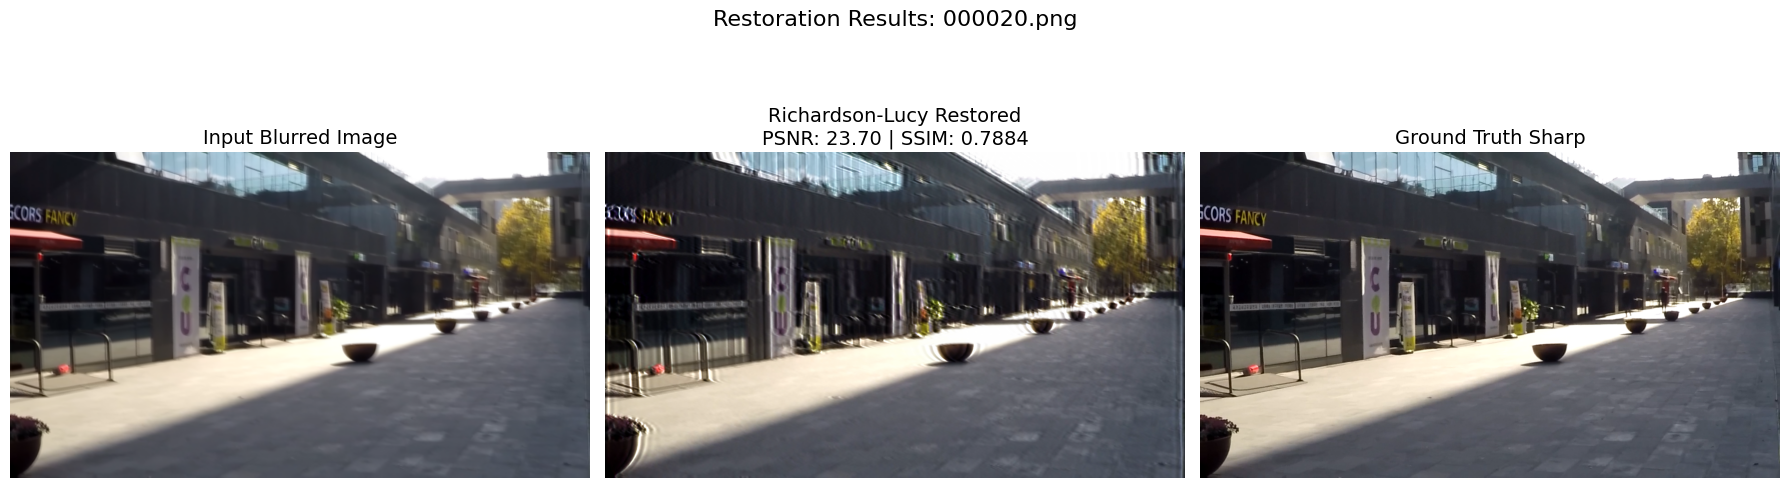

In [39]:
import matplotlib.pyplot as plt

def visualize_results(blur_img, deblur_img, sharp_img, fname, psnr, ssim):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(blur_img)
    axes[0].set_title(f"Input Blurred Image", fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(deblur_img)
    axes[1].set_title(f"Richardson-Lucy Restored\nPSNR: {psnr:.2f} | SSIM: {ssim:.4f}", fontsize=14)
    axes[1].axis('off')

    axes[2].imshow(sharp_img)
    axes[2].set_title("Ground Truth Sharp", fontsize=14)
    axes[2].axis('off')

    plt.suptitle(f"Restoration Results: {fname}", fontsize=16)
    plt.tight_layout()
    plt.show()

# Loading a sample from the 'Medium' category for visualization
sample_fname = "000020.png"
test_img_path = strat_path / "test/Medium/blur" / sample_fname
test_sharp_path = strat_path / "test/Medium/sharp" / sample_fname

if test_img_path.exists():
    blur_viz = cv2.cvtColor(cv2.imread(str(test_img_path)), cv2.COLOR_BGR2RGB)
    sharp_viz = cv2.cvtColor(cv2.imread(str(test_sharp_path)), cv2.COLOR_BGR2RGB)
    psf_viz = get_motion_psf(size=15, angle=0)
    deblur_viz = deblur_richardson_lucy_rgb(blur_viz, psf_viz, iterations=20)

    # Calculate specific metrics for the plot
    gray_sharp = cv2.cvtColor(sharp_viz, cv2.COLOR_RGB2GRAY)
    gray_deblur = cv2.cvtColor(deblur_viz, cv2.COLOR_RGB2GRAY)
    psnr_viz = metrics.peak_signal_noise_ratio(gray_sharp, gray_deblur)
    ssim_viz = metrics.structural_similarity(gray_sharp, gray_deblur, data_range=255)

    visualize_results(blur_viz, deblur_viz, sharp_viz, sample_fname, psnr_viz, ssim_viz)
else:
    print(f"File {sample_fname} not found for visualization. Please check the path.")

In [35]:
!pip install ultralytics

import os
from ultralytics import YOLO
from tqdm import tqdm

# 1. Load the largest YOLOv8 model for best pseudo-label quality
model = YOLO('yolov8x.pt')

def generate_pseudo_labels(base_dir):
    # We generate labels based on the 'sharp' ground truth images
    # This allows us to see how detection fails on 'blur' versus 'deblur'
    splits = ['train', 'val', 'test']
    categories = ['Mild', 'Medium', 'Severe']

    for split in splits:
        for cat in categories:
            sharp_path = Path(base_dir) / split / cat / "sharp"
            label_path = Path(base_dir) / split / cat / "labels"
            label_path.mkdir(parents=True, exist_ok=True)

            images = list(sharp_path.glob("*.png"))
            if not images: continue

            print(f"Generating labels for {split}/{cat}...")
            for img_p in tqdm(images):
                results = model.predict(img_p, conf=0.4, verbose=False)

                # Save labels in YOLO format (class x_center y_center width height)
                label_file = label_path / f"{img_p.stem}.txt"
                results[0].save_txt(str(label_file))

# Execute labeling
strat_path = Path("/content/drive/MyDrive/gopro_deblur/processed_stratified")
generate_pseudo_labels(strat_path)
print("\nLabel generation complete. Dataset is now ready for Task 3 & 4.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Generating labels for train/Mild...


100%|██████████| 245/245 [13:18<00:00,  3.26s/it]


Generating labels for train/Medium...


100%|██████████| 237/237 [12:49<00:00,  3.25s/it]


Generating labels for train/Severe...


...

Generating labels for test/Medium...


100%|██████████| 51/51 [02:43<00:00,  3.21s/it]


Generating labels for test/Severe...


100%|██████████| 51/51 [02:43<00:00,  3.20s/it]


Label generation complete. Dataset is now ready for Task 3 & 4.


Deblurring 000020.png for inference...
Running YOLO inference...


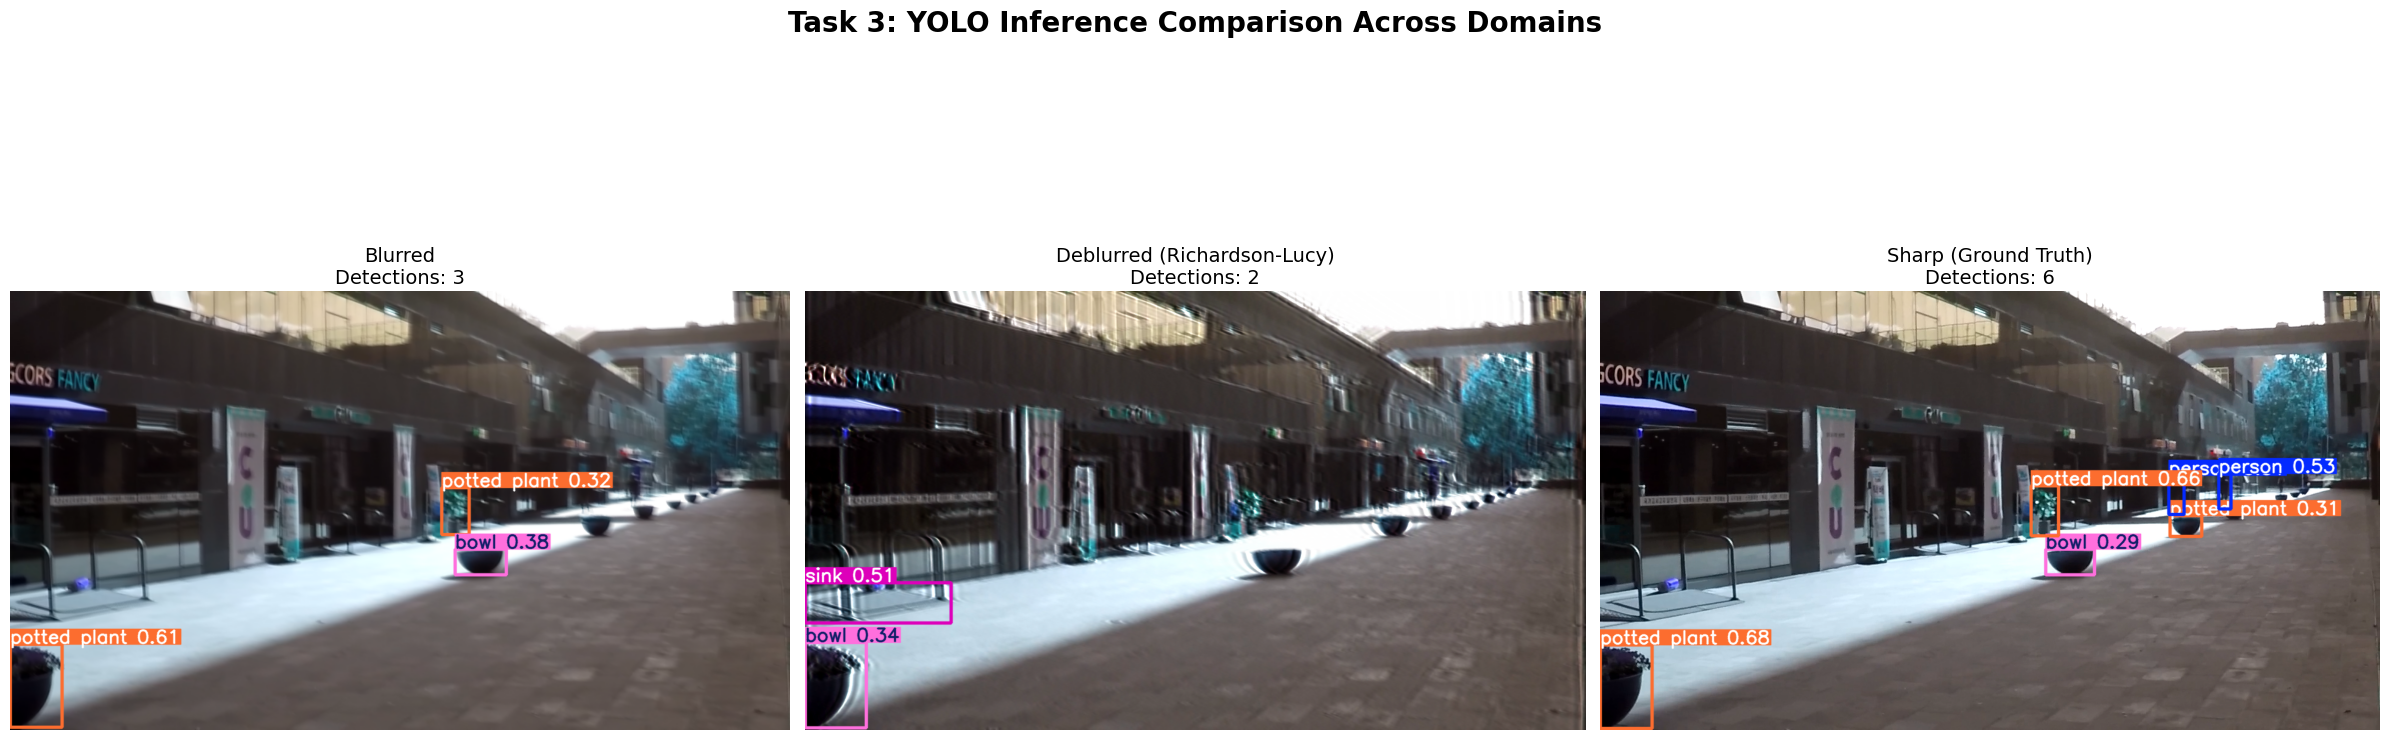

In [37]:
# 1. Initialize YOLO and deblurring logic
# Using the model already loaded in previous steps or loading it if needed
try:
    model
except NameError:
    model = YOLO('yolov8x.pt')

def get_motion_psf(size=15, angle=0):
    psf = np.zeros((size, size))
    center = size // 2
    cv2.line(psf, (0, center), (size - 1, center), 1, thickness=1)
    M = cv2.getRotationMatrix2D((center, center), angle, 1.0)
    psf = cv2.warpAffine(psf, M, (size, size))
    return psf / psf.sum()

def deblur_richardson_lucy_rgb(image, psf, iterations=20):
    pad_size = psf.shape[0]
    padded_img = np.pad(image, ((pad_size, pad_size), (pad_size, pad_size), (0, 0)), mode='symmetric')
    restored = np.zeros_like(padded_img, dtype=np.float64)
    for c in range(3):
        channel = padded_img[:, :, c] / 255.0
        restored[:, :, c] = restoration.richardson_lucy(channel, psf, num_iter=iterations)
    restored_cropped = restored[pad_size:-pad_size, pad_size:-pad_size, :]
    return np.clip(restored_cropped * 255, 0, 255).astype(np.uint8)

# 2. Path Setup
base_strat_path = Path("/content/drive/MyDrive/gopro_deblur/processed_stratified")
sample_fname = "000020.png"

blur_path = base_strat_path / "test" / "Medium" / "blur" / sample_fname
sharp_path = base_strat_path / "test" / "Medium" / "sharp" / sample_fname

if blur_path.exists() and sharp_path.exists():
    img_blur = cv2.cvtColor(cv2.imread(str(blur_path)), cv2.COLOR_BGR2RGB)
    img_sharp = cv2.cvtColor(cv2.imread(str(sharp_path)), cv2.COLOR_BGR2RGB)

    print(f"Deblurring {sample_fname} for inference...")
    psf = get_motion_psf(size=15, angle=0)
    img_deblur = deblur_richardson_lucy_rgb(img_blur, psf, iterations=20)

    # 3. Run YOLO Inference
    print("Running YOLO inference...")
    res_blur = model.predict(img_blur, conf=0.25, verbose=False)[0]
    res_deblur = model.predict(img_deblur, conf=0.25, verbose=False)[0]
    res_sharp = model.predict(img_sharp, conf=0.25, verbose=False)[0]

    # 4. Extract plotted images with bounding boxes
    plot_blur = res_blur.plot()[..., ::-1]
    plot_deblur = res_deblur.plot()[..., ::-1]
    plot_sharp = res_sharp.plot()[..., ::-1]

    # 5. Visualize Side-by-Side
    fig, axes = plt.subplots(1, 3, figsize=(24, 10))

    axes[0].imshow(plot_blur)
    axes[0].set_title(f"Blurred\nDetections: {len(res_blur.boxes)}", fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(plot_deblur)
    axes[1].set_title(f"Deblurred (Richardson-Lucy)\nDetections: {len(res_deblur.boxes)}", fontsize=14)
    axes[1].axis('off')

    axes[2].imshow(plot_sharp)
    axes[2].set_title(f"Sharp (Ground Truth)\nDetections: {len(res_sharp.boxes)}", fontsize=14)
    axes[2].axis('off')

    plt.suptitle("Task 3: YOLO Inference Comparison Across Domains", fontsize=20, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Sample files not found. Please ensure the stratified split completed successfully.")

In [40]:
import yaml

# 1. Paths configuration
strat_path = Path("/content/drive/MyDrive/gopro_deblur/processed_stratified")
yolo_dataset_path = Path("/content/yolo_dataset")
splits = ['train', 'val']
categories = ['Mild', 'Medium', 'Severe']

# Create YOLO strict directory structure
for split in splits:
    (yolo_dataset_path / "images" / split).mkdir(parents=True, exist_ok=True)
    (yolo_dataset_path / "labels" / split).mkdir(parents=True, exist_ok=True)

# 2. Optimized Deblurring for Dataset Prep
def get_psf_fixed(size=15):
    psf = np.zeros((size, size))
    cv2.line(psf, (0, size//2), (size - 1, size//2), 1, thickness=1)
    return psf / psf.sum()

def fast_deblur_save(img_path, save_path, psf_kernel):
    # Reading and processing
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    pad = psf_kernel.shape[0]
    padded = np.pad(img, ((pad, pad), (pad, pad), (0, 0)), mode='symmetric')

    restored = np.zeros_like(padded, dtype=np.float64)
    for c in range(3):
        # 10 iterations for balanced speed/quality during batch prep
        restored[:, :, c] = restoration.richardson_lucy(padded[:, :, c] / 255.0, psf_kernel, num_iter=10)

    cropped = np.clip(restored[pad:-pad, pad:-pad, :] * 255, 0, 255).astype(np.uint8)
    cv2.imwrite(str(save_path), cv2.cvtColor(cropped, cv2.COLOR_RGB2BGR))

# 3. Construct the YOLO Dataset
print("Constructing YOLO dataset and deblurring images (this may take a while)... ")
psf_batch = get_psf_fixed()

for split in splits:
    for cat in categories:
        blur_dir = strat_path / split / cat / "blur"
        label_dir = strat_path / split / cat / "labels"

        if not blur_dir.exists(): continue

        images = list(blur_dir.glob("*.png"))
        print(f"Processing {split}/{cat}: {len(images)} images...")

        for img_path in tqdm(images):
            # Match image with its corresponding pseudo-label
            label_file = label_dir / f"{img_path.stem}.txt"
            if label_file.exists():
                save_img_path = yolo_dataset_path / "images" / split / img_path.name

                # Deblur and save
                if not save_img_path.exists():
                    fast_deblur_save(img_path, save_img_path, psf_batch)

                # Copy label file
                dest_label = yolo_dataset_path / "labels" / split / label_file.name
                if not dest_label.exists():
                    shutil.copy(label_file, dest_label)

# 4. Generate data.yaml for YOLOv8 training
# Mapping standard COCO classes used by the pre-trained YOLOv8x
coco_classes = {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microwave', 69: 'oven', 70: 'toaster', 71: 'sink', 72: 'refrigerator', 73: 'book', 74: 'clock', 75: 'vase', 76: 'scissors', 77: 'teddy bear', 78: 'hair drier', 79: 'toothbrush'}

yaml_data = {
    'path': str(yolo_dataset_path.absolute()),
    'train': 'images/train',
    'val': 'images/val',
    'names': coco_classes
}

yaml_path = yolo_dataset_path / "data.yaml"
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_data, f, default_flow_style=False)

print(f"\n✅ Automated Pipeline Complete!")
print(f"Dataset ready at: {yolo_dataset_path}")
print(f"Config file created at: {yaml_path}")

Constructing YOLO dataset and deblurring images (this may take a while)... 
Processing train/Mild: 245 images...


100%|██████████| 245/245 [14:47<00:00,  3.62s/it]


Processing train/Medium: 237 images...


100%|██████████| 237/237 [13:45<00:00,  3.48s/it]


Processing train/Severe: 238 images...


...

Processing val/Medium: 51 images...


100%|██████████| 51/51 [03:06<00:00,  3.66s/it]


Processing val/Severe: 51 images...


100%|██████████| 51/51 [02:46<00:00,  3.27s/it]


✅ Automated Pipeline Complete!
Dataset ready at: /content/yolo_dataset
Config file created at: /content/yolo_dataset/data.yaml
